# Hemoglobin Balance

You have 5 L of blood with a hemoglobin concentration of 150 g/L and a hematocrit of 45% (A normal healthy human). You lose 1.5 L of blood from a leg injury, but the body quickly restores the total blood volume to 5 L by adding plasma.

*Hint: Total hemoglobin is the hemoglobin remaining in the body; hematocrit is the fraction of red blood cells in the restored blood volume; hemoglobin concentration is total hemoglobin divided by total blood volume.*

**Hints / breadcrumbs:**

1. **Total hemoglobin initially:** multiply the initial concentration by total blood volume.
2. **Blood volume restoration:** after losing blood, the body quickly restores blood volume to normal by adding fluid (plasma) — red blood cells are not replaced immediately.
3. **New hematocrit:** fraction of red blood cells in the restored blood volume.
4. **New hemoglobin concentration:** total hemoglobin divided by restored blood volume.
5. **Total hemoglobin after loss:** only the hemoglobin that remains in the body (does not get replaced immediately).

## Exercise: Hemoglobin Balance
Using the information above, answer questions A-C.

* **A.** What would the new hemoglobin `concentration`, `hematocrit`, and `total amount of hemoglobin` (measured in grams) be in the blood immediately after you have lost 1.5 L of blood and the blood volume has returned to 5 L (Assume no Hemoglobin has yet to be restored, i.e. remove 1.5 blood, replace with 1.5L of salt water)?

In [ ]:
C0 = 150.0 # g/L concentration prior to bloodloss
Htc = 45.0 # hematocrit value prior to bloodloss
V_blood = 5.0 # Volume of blood, before bloodloss
V_loss = 1.5 # Volume of lossed blood




* **B.** Hemoglobin Recovery After Blood Loss

Following your blood loss in question A, hemoglobin is replenished over time. The **rate of hemoglobin production** depends on iron recycling from destroyed red blood cells, erythropoietin, and mobilization of iron from ferritin stores. Assume:

* The average lifespan of a red blood cell is **120 days**, giving a natural removal rate of hemoglobin.
* The rate of new hemoglobin production is **constant at 6.3 g/day**.

Solve the differential equation for hemoglobin:
$$ \frac{dHb}{dt} = - k Hb + S $$
where ($k=\frac{1}{\text{average hemoglobin lifespan}}$) is the rate constant related to RBC lifespan, and ($S$) is the constant production rate. Solve this equation to find the hemoglobin concentration ($Hb(t)$) over time.

*Hint: The solution is of the form: $Hb = Hb_\infty + (Hb_0 - Hb_\infty) e^{-kt}$, where $Hb_\infty =\frac{S}{k}$*

* **C.** How much time it takes to recover one-half of the lost Hb ($t_½$), i.e. $Hb($t_½)$?

Following your previous blood loss scenario and the hemoglobin recovery model from question B, estimate how long it takes to recover half of the hemoglobin that was lost. 
When solving the equation, it turns out that, if $k$ and $S$ remains constant, $t_½$ is only affected by $k$. Thats quite interesting. 
Using the hints below, find the answer.

**Hints / breadcrumbs:**

1. Use the **solution from question B**: $Hb(t) = Hb_\infty + (Hb_0 - Hb_\infty) e^{-k t}$
2. Define **half of the lost hemoglobin** as the point where ($Hb(t)$) has reached **halfway from ($Hb_0$) to ($Hb_\infty$)**.
3. Solve for $t=t_½$

4. *The solution will be $t_½=-\frac{\ln{½}}{k}=\frac{\ln(2)}{k} \approx 83.2\ \text{days}$*

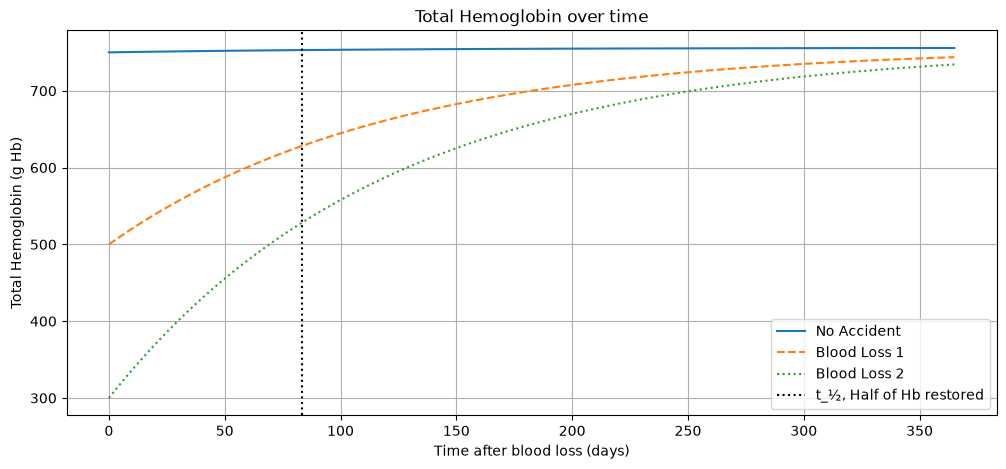

In [6]:
# %load files/run_hemoglobin_model.py
import numpy as np
import matplotlib.pyplot as plt

from files.hemoglobin_model import hemoglobin_model

t_max = 365.0
t = np.linspace(0.0, t_max, 100)  # days
k = 1.0 / 120.0  # fractional turnover rate, uddrivelsesraten / dag
S = 6.3  # rate of hemoglobin production gHb / dag
Hb_no_accident = hemoglobin_model(Hb0=750, t=t, k=k, S=S)
Hb_bloodloss = hemoglobin_model(Hb0=500, t=t, k=k, S=S)
Hb_bloodloss2 = hemoglobin_model(Hb0=300.0, t=t, k=k, S=S)
t_half = np.log(2) / k  # days
# Plot
plt.figure(figsize=(12, 5))

plt.plot(t, Hb_no_accident, label="No Accident")
plt.plot(t, Hb_bloodloss, label="Blood Loss 1", linestyle="--")
plt.plot(t, Hb_bloodloss2, label="Blood Loss 2", linestyle=":")
plt.axvline(t_half, color="k", linestyle=":", label="t_½, Half of Hb restored")
plt.xlabel("Time after blood loss (days)")
plt.ylabel("Total Hemoglobin (g Hb)")
plt.title("Total Hemoglobin over time")
plt.legend()
plt.grid(True)
plt.show()
